In [2]:
import nltk
import string
from nltk.tokenize import word_tokenize
nltk.download('punkt')


[nltk_data] Downloading package punkt to /home/tamer/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
from nltk.corpus import stopwords

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/tamer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to /home/tamer/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
lemmatizer = WordNetLemmatizer()

In [4]:
reviews = ["I loved the movie. It was amazing!", 
"The movie was okay.", 
"I hated the movie. It was boring."]

In [19]:
def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    stop_words = stopwords.words('english')
    tokens = [word for word in tokens if word not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_tokens)

In [20]:
preprocess(reviews[0])

'loved movie amazing'

In [21]:
for review in reviews:
    print(preprocess(review))

loved movie amazing
movie okay
hated movie boring


In [22]:
cleaned_reviews = [preprocess(review) for review in reviews]
print(cleaned_reviews)

['loved movie amazing', 'movie okay', 'hated movie boring']


# BoW

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
vectorizer.fit(cleaned_reviews)


CountVectorizer()

In [ ]:
vectorizer.get_feature_names_out() # Get the feature names (unique words) from the vectorizer (VOCABULARY BUILDER)

array(['amazing', 'boring', 'hated', 'loved', 'movie', 'okay'],
      dtype=object)

In [25]:
X=vectorizer.transform(cleaned_reviews)
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (3, 6)>

In [26]:
X.toarray()

array([[1, 0, 0, 1, 1, 0],
       [0, 0, 0, 0, 1, 1],
       [0, 1, 1, 0, 1, 0]])

### Word Frequencies

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
# In NumPy, axis=0 refers to the rows. When you sum along axis=0, you are telling Python: "Go through every column and add all the rows together."
word_count = np.sum(X.toarray(), axis=0)
word_count

array([1, 1, 1, 1, 3, 1])

In [30]:
words = vectorizer.get_feature_names_out()
words

array(['amazing', 'boring', 'hated', 'loved', 'movie', 'okay'],
      dtype=object)

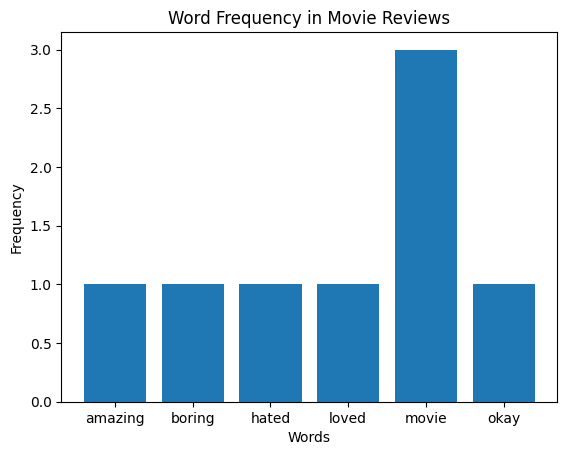

In [31]:
plt.bar(words, word_count)
plt.title("Word Frequency in Movie Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()